In [ ]:
import pandas as pd

df = pd.read_csv("customer_shopping_data.csv")
df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [ ]:
df.shape

(99457, 10)

In [ ]:
df.isnull()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
99452,False,False,False,False,False,False,False,False,False,False
99453,False,False,False,False,False,False,False,False,False,False
99454,False,False,False,False,False,False,False,False,False,False
99455,False,False,False,False,False,False,False,False,False,False


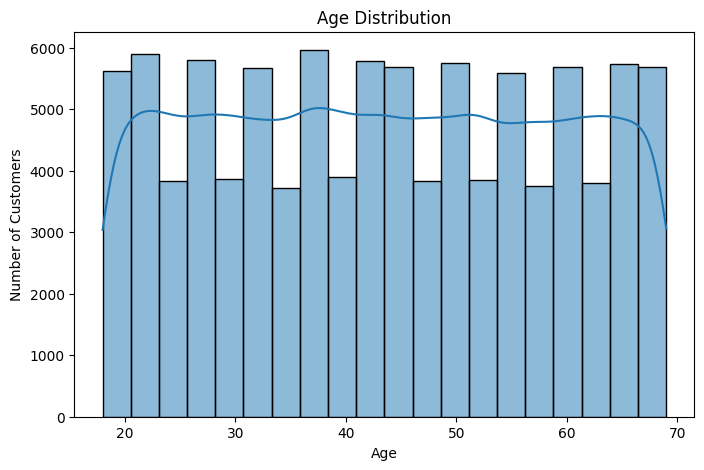

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins = 20, kde = True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

Text(0, 0.5, 'Number of Customers')

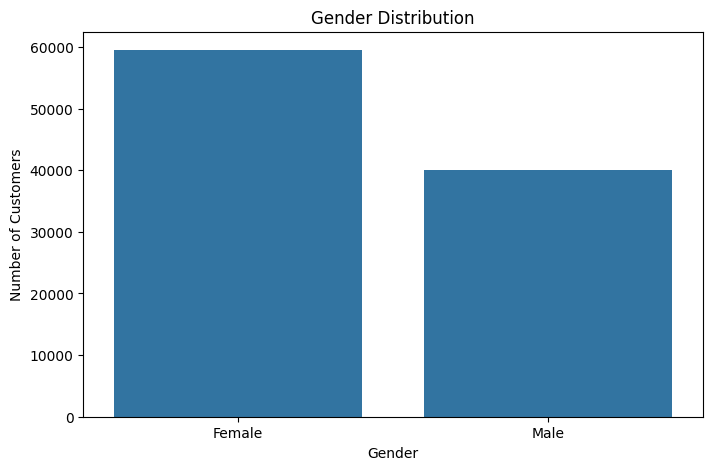

In [ ]:
plt.figure(figsize = (8,5))
sns.countplot(x= 'gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

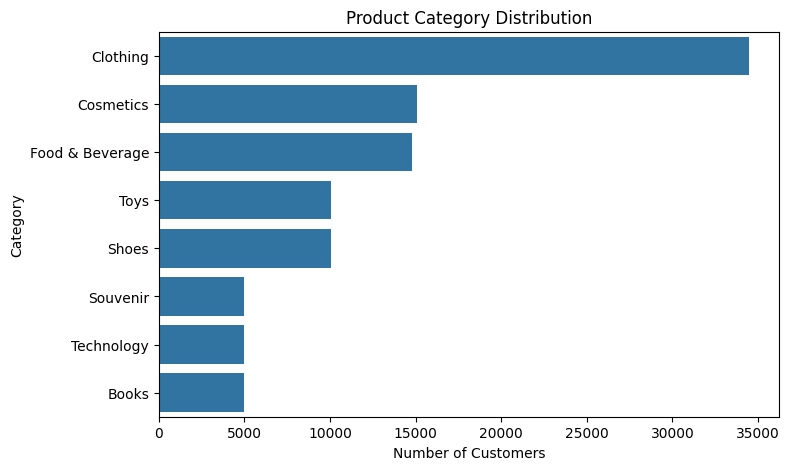

In [ ]:
plt.figure(figsize = (8,5))
sns.countplot(
    y = 'category',
    data = df,
    order = df['category'].value_counts().index
)

plt.title("Product Category Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Category")
plt.show()

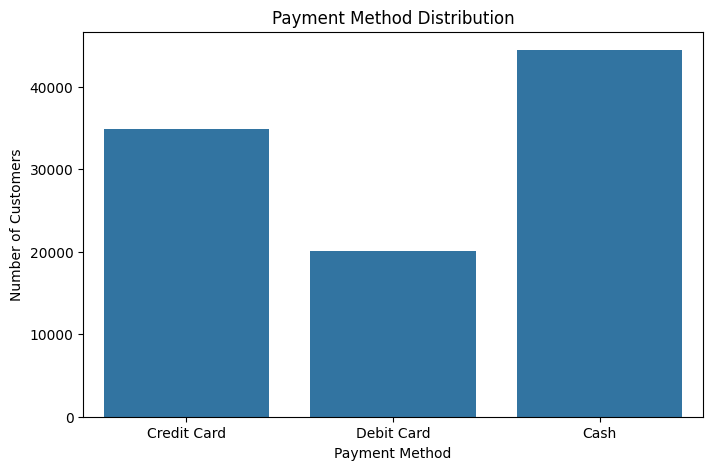

In [ ]:
plt.figure(figsize = (8,5))
sns.countplot(x = 'payment_method', data = df)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.show()

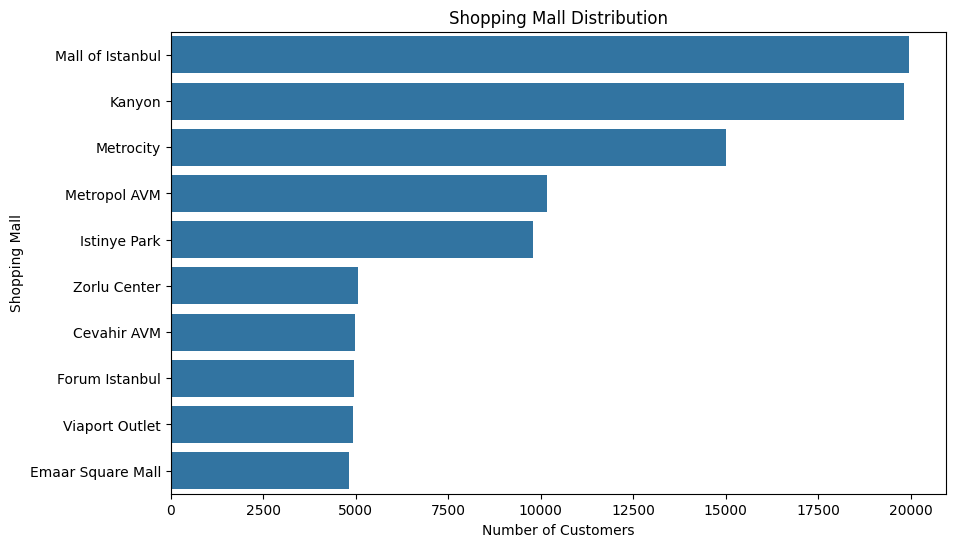

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='shopping_mall',
    data=df,
    order=df['shopping_mall'].value_counts().index
)

plt.title("Shopping Mall Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Shopping Mall")

plt.show()

In [ ]:
features = df[['age', 'quantity', 'price']]

features.head()

,age,quantity,price
0,28,5,1500.40
1,21,3,1800.51
2,20,1,300.08
3,66,5,3000.85
4,53,4,60.60


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)
print(scaled_features)

[[-1.02916019e+00  1.41298366e+00  8.61837078e-01]
 [-1.49613885e+00 -2.42644985e-03  1.18070281e+00]
 [-1.56285009e+00 -1.41783656e+00 -4.13498363e-01]
 ...
 [ 1.30573309e+00 -7.10131503e-01 -7.21218512e-01]
 [ 8.38754436e-01  7.05278603e-01  3.73015182e+00]
 [-4.95470299e-01 -2.42644985e-03 -6.94942981e-01]]


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

clusters[:10]

array([0, 0, 2, 0, 1, 0, 2, 2, 1, 2], dtype=int32)

In [ ]:
df["Cluster"] = clusters

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Cluster
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,0
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,0
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,2
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,0
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,1


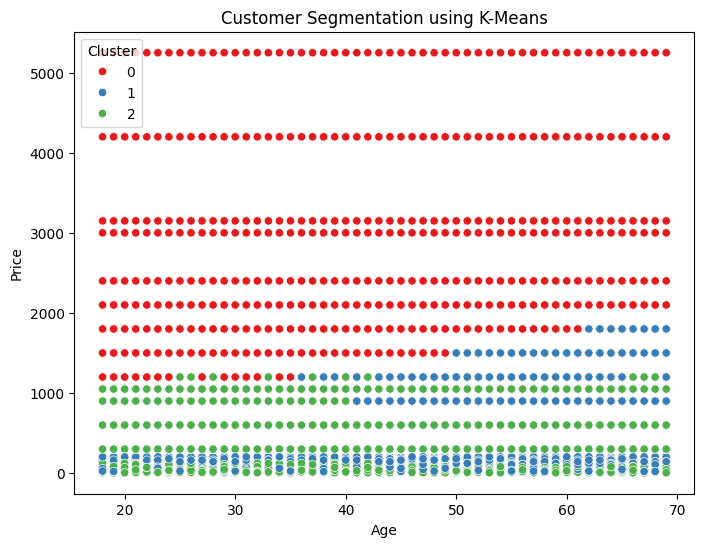

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["age"],
    y=df["price"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()